# Exploratory Model: ResNet34 U-Net — Parking Space Segmentation

## Architecture at a glance

| Component | Detail |
|---|---|
| **Backbone** | ResNet-34 (pretrained on ImageNet) |
| **Architecture** | U-Net (encoder-decoder + skip connections) |
| **Input channels** | **3** — RGB image, resized to 256 × 256 px |
| **Output channels** | **3** — one score map per class: `0 = background`, `1 = space-empty`, `2 = space-occupied` |
| **Loss** | `CrossEntropyLoss` (multi-class pixel classification) |
| **Primary metric** | Mean IoU (mIoU) across all 3 classes |
| **Epochs** | 30 (early stopping on val mIoU) |

### Why U-Net + ResNet34?
U-Net's skip connections preserve fine-grained spatial detail (parking-space boundaries) that a plain encoder would lose. ResNet-34 is lightweight enough to fine-tune quickly while still benefiting from rich ImageNet features.

### Annotation strategy
The PKLot COCO annotations are bounding boxes. We **rasterize** them into dense pixel masks at load time: every pixel inside a bbox receives that bbox's category id (1 or 2); all other pixels are 0 (background).

### Dataset splits
| Split | Images | Annotations |
|---|---|---|
| `train` | 8 691 | 497 856 |
| `valid` | 2 483 | 143 316 |
| `test` | 1 242 | 70 684 |

In [10]:
# Install required packages (run once)
%pip install -q segmentation-models-pytorch albumentations timm

Note: you may need to restart the kernel to use updated packages.


In [11]:
%matplotlib inline

import json
import time
from collections import defaultdict
from pathlib import Path

import albumentations as A
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch
import torch.nn as nn
from albumentations.pytorch import ToTensorV2
from PIL import Image
from torch.utils.data import DataLoader, Dataset
import segmentation_models_pytorch as smp

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: mps


## 1 · Configuration

In [12]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_ROOT = Path("../Data/raw")
CHECKPOINT_DIR = Path("../checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

# ── Model I/O ──────────────────────────────────────────────────────────────
IN_CHANNELS  = 3   # RGB
NUM_CLASSES  = 3   # 0=background  1=space-empty  2=space-occupied
IMG_SIZE     = 256 # resize target (original images are 640×640)

# ── Training ───────────────────────────────────────────────────────────────
EPOCHS       = 30
BATCH_SIZE   = 16
LR           = 1e-4
LR_PATIENCE  = 5    # ReduceLROnPlateau patience
ES_PATIENCE  = 10   # early-stopping patience (epochs without val mIoU improvement)

# ── Quick-run subsampling ──────────────────────────────────────────────────
SUBSET_FRACTION = 0.05   # fraction of train/val to use; set to 1.0 to use the full dataset

# ── ImageNet normalisation stats (used by ResNet34 pretrained weights) ─────
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# ── Class labels & colours for visualisation ──────────────────────────────
CLASS_NAMES  = ["background", "space-empty", "space-occupied"]
CLASS_COLORS = np.array([
    [0,   0,   0  ],   # black  – background
    [0,   200, 0  ],   # green  – empty
    [220, 50,  50 ],   # red    – occupied
], dtype=np.uint8)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## 2 · Dataset

### Mask generation
For each image we build a `(H, W)` integer mask by iterating its COCO bboxes and filling each rectangle with its `category_id` (1 or 2). Pixels not covered by any bbox remain 0 (background).

> **Note:** When two bboxes overlap, the last-drawn category wins. Overlap is rare in PKLot, so this is acceptable.


All the images for this first fine-tuning model are get from the PKLot (A robust dataset for parking lot classification, Expert Systems with Applications, Almeida, P., Oliveira, L. S., Silva Jr, E., Britto Jr, A., Koerich, A). Es un DataSet the Parking Images of 3 universities in Brazil. The Dataset has the labels of where is the parking and where we have a parked car. 

We don't have the data on the github because for avoiding uploading large files there, but you it can easily downloaded here https://web.inf.ufpr.br/vri/databases/parking-lot-database/ 

In [13]:
class ParkingLotDataset(Dataset):
    """
    Input  : 3-channel RGB image  →  tensor (3, H, W),  float32, ImageNet-normalised
    Output : pixel-wise class mask →  tensor (H, W),     int64
             class 0 = background
             class 1 = space-empty
             class 2 = space-occupied
    """

    def __init__(self, root: Path, split: str, transform=None, img_size: int = 256):
        self.split_dir = root / split
        self.img_size  = img_size
        self.transform = transform

        with open(self.split_dir / "_annotations.coco.json") as f:
            coco = json.load(f)

        self.images = coco["images"]

        # Pre-index: image_id → list of annotations
        self._ann_index = defaultdict(list)
        for ann in coco["annotations"]:
            self._ann_index[ann["image_id"]].append(ann)

    # ------------------------------------------------------------------ #
    def __len__(self):
        return len(self.images)

    # ------------------------------------------------------------------ #
    def _make_mask(self, img_id: int, orig_h: int, orig_w: int) -> np.ndarray:
        mask = np.zeros((orig_h, orig_w), dtype=np.uint8)
        for ann in self._ann_index[img_id]:
            x, y, w, h = ann["bbox"]
            x1, y1 = int(x), int(y)
            x2, y2 = min(int(x + w), orig_w), min(int(y + h), orig_h)
            mask[y1:y2, x1:x2] = ann["category_id"]  # 1 or 2
        return mask

    # ------------------------------------------------------------------ #
    def __getitem__(self, idx):
        info = self.images[idx]

        image = np.array(
            Image.open(self.split_dir / info["file_name"]).convert("RGB")
            .resize((self.img_size, self.img_size))
        )  # (H, W, 3)  uint8

        mask = self._make_mask(info["id"], info["height"], info["width"])
        mask = np.array(
            Image.fromarray(mask).resize((self.img_size, self.img_size), Image.NEAREST)
        )  # (H, W)  uint8 — NEAREST keeps integer labels exact

        if self.transform:
            out   = self.transform(image=image, mask=mask)
            image = out["image"]   # tensor (3, H, W)  float32
            mask  = out["mask"].long()  # tensor (H, W)  int64
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
            mask  = torch.from_numpy(mask).long()

        return image, mask

## 3 · Augmentation & DataLoaders

In [14]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

# ── Datasets ───────────────────────────────────────────────────────────────
train_ds = ParkingLotDataset(DATA_ROOT, "train", transform=train_transform, img_size=IMG_SIZE)
val_ds   = ParkingLotDataset(DATA_ROOT, "valid", transform=val_transform,   img_size=IMG_SIZE)
test_ds  = ParkingLotDataset(DATA_ROOT, "test",  transform=val_transform,   img_size=IMG_SIZE)

print(f"Original sizes  →  Train: {len(train_ds):>5}  |  Val: {len(val_ds):>5}  |  Test: {len(test_ds):>5}")

# ── Subsample train and val ────────────────────────────────────────────────
rng         = np.random.default_rng(SEED)
train_sub_n = int(len(train_ds) * SUBSET_FRACTION)
val_sub_n   = int(len(val_ds)   * SUBSET_FRACTION)
train_idx   = rng.choice(len(train_ds), size=train_sub_n, replace=False).tolist()
val_idx     = rng.choice(len(val_ds),   size=val_sub_n,   replace=False).tolist()
train_ds    = torch.utils.data.Subset(train_ds, train_idx)
val_ds      = torch.utils.data.Subset(val_ds,   val_idx)

print(f"Subsampled {SUBSET_FRACTION:.0%}   →  Train: {len(train_ds):>5}  |  Val: {len(val_ds):>5}")

# ── DataLoaders ─────────────────────────────────────────────────────────────
# num_workers=0 avoids multiprocessing pickle errors when running in a notebook
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

Original sizes  →  Train:  8691  |  Val:  2483  |  Test:  1242
Subsampled 5%   →  Train:   434  |  Val:   124


### Quick sanity-check: visualise one batch

Image batch shape : torch.Size([16, 3, 256, 256])   dtype=torch.float32
Mask  batch shape : torch.Size([16, 256, 256])    dtype=torch.int64
Mask unique values: [0, 1, 2]


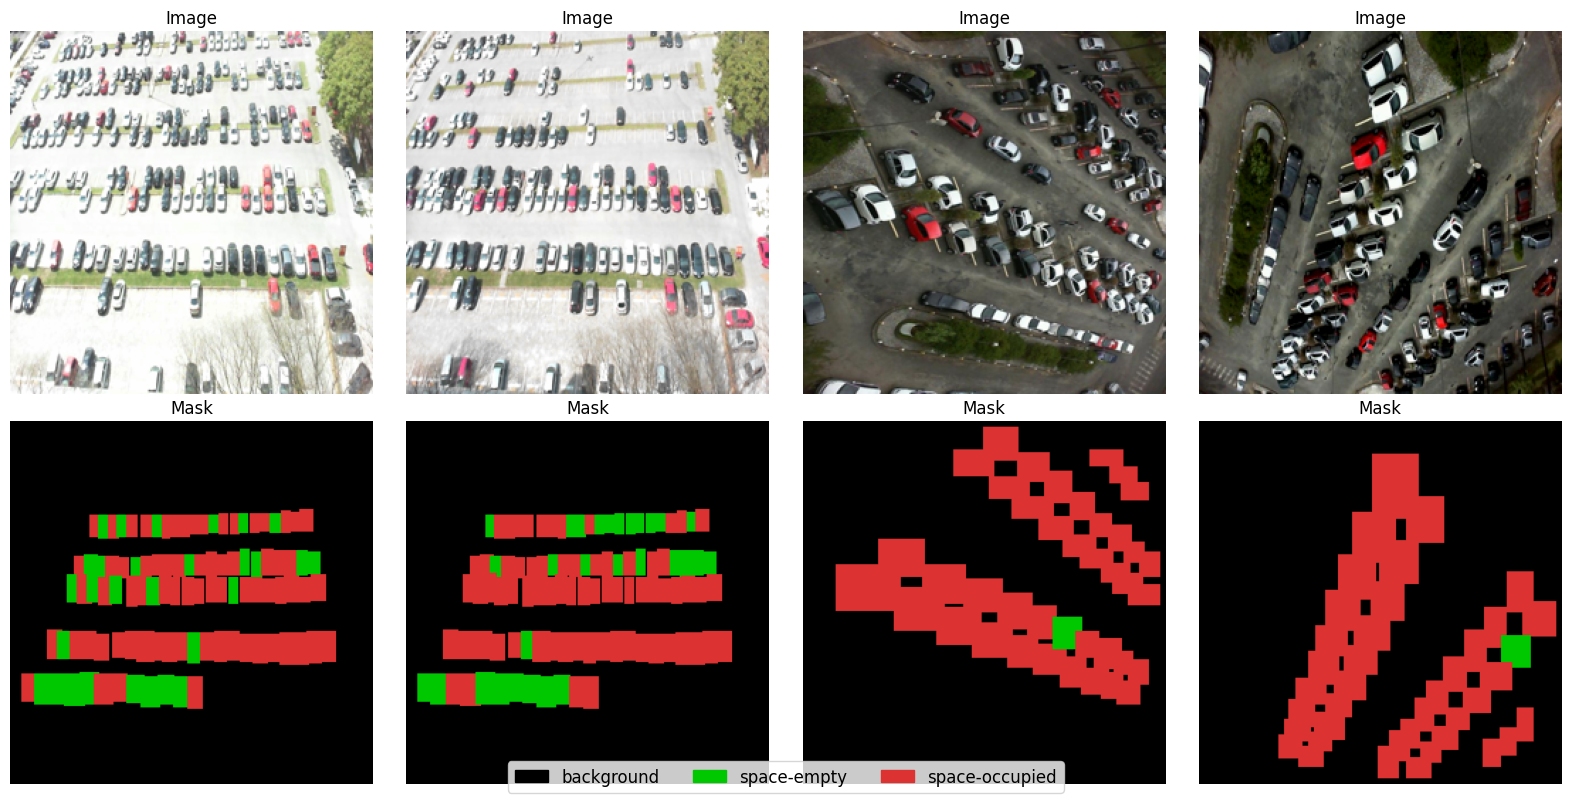

In [15]:
def mask_to_rgb(mask: np.ndarray) -> np.ndarray:
    """Convert integer class mask to an RGB image using CLASS_COLORS."""
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cls_id, color in enumerate(CLASS_COLORS):
        rgb[mask == cls_id] = color
    return rgb

def denormalise(tensor: torch.Tensor) -> np.ndarray:
    """Undo ImageNet normalisation for display."""
    mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
    std  = np.array(IMAGENET_STD).reshape(3, 1, 1)
    img  = tensor.cpu().numpy() * std + mean
    return np.clip(img.transpose(1, 2, 0), 0, 1)

images, masks = next(iter(train_loader))
print(f"Image batch shape : {images.shape}   dtype={images.dtype}")
print(f"Mask  batch shape : {masks.shape}    dtype={masks.dtype}")
print(f"Mask unique values: {masks.unique().tolist()}")

n_show = 4
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))
for i in range(n_show):
    axes[0, i].imshow(denormalise(images[i]))
    axes[0, i].set_title("Image"); axes[0, i].axis("off")
    axes[1, i].imshow(mask_to_rgb(masks[i].numpy()))
    axes[1, i].set_title("Mask");  axes[1, i].axis("off")

legend = [
    mpatches.Patch(color=CLASS_COLORS[i] / 255, label=CLASS_NAMES[i])
    for i in range(NUM_CLASSES)
]
fig.legend(handles=legend, loc="lower center", ncol=3, fontsize=12)
plt.tight_layout()
plt.show()

## 4 · Model

```
Input  →  [3 × 256 × 256]  (RGB, ImageNet-normalised)
           ↓
     ResNet-34 encoder (5 stages, pretrained on ImageNet)
           ↓  skip connections
     U-Net decoder (4 up-sampling blocks)
           ↓
Output →  [3 × 256 × 256]  (raw logits per class; argmax → class index)
```

`encoder_weights="imagenet"` loads the pretrained ResNet-34 backbone. The decoder head is randomly initialised and trained from scratch.

In [16]:
model = smp.Unet(
    encoder_name    = "resnet34",
    encoder_weights = "imagenet",   # pretrained ResNet-34 backbone
    in_channels     = IN_CHANNELS,  # 3 — RGB
    classes         = NUM_CLASSES,  # 3 — background / empty / occupied
    activation      = None,         # raw logits; CrossEntropyLoss handles softmax internally
)
model = model.to(DEVICE)

# Quick parameter count
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Dry run to confirm shapes
with torch.no_grad():
    dummy_in  = torch.randn(2, IN_CHANNELS, IMG_SIZE, IMG_SIZE).to(DEVICE)
    dummy_out = model(dummy_in)
print(f"\nDry run — input : {tuple(dummy_in.shape)}")
print(f"Dry run — output: {tuple(dummy_out.shape)}   (batch, classes, H, W)")

Total parameters    : 24,436,659
Trainable parameters: 24,436,659

Dry run — input : (2, 3, 256, 256)
Dry run — output: (2, 3, 256, 256)   (batch, classes, H, W)


## 5 · Loss, Optimiser & Scheduler

In [17]:
criterion = nn.CrossEntropyLoss()                          # expects logits (B,C,H,W) + targets (B,H,W)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=LR_PATIENCE  # verbose removed (dropped in PyTorch ≥ 2.2)
)

def compute_miou(logits: torch.Tensor, targets: torch.Tensor, num_classes: int = NUM_CLASSES) -> float:
    """Compute mean IoU over all classes (including background)."""
    preds = logits.argmax(dim=1)  # (B, H, W)
    iou_per_class = []
    for cls in range(num_classes):
        pred_cls   = preds == cls
        target_cls = targets == cls
        intersection = (pred_cls & target_cls).sum().float()
        union        = (pred_cls | target_cls).sum().float()
        iou_per_class.append(((intersection + 1e-6) / (union + 1e-6)).item())
    return float(np.mean(iou_per_class))

def compute_fg_miou(logits: torch.Tensor, targets: torch.Tensor) -> float:
    """Mean IoU over foreground classes only (1=empty, 2=occupied)."""
    preds = logits.argmax(dim=1)
    iou_per_class = []
    for cls in [1, 2]:
        pred_cls   = preds == cls
        target_cls = targets == cls
        intersection = (pred_cls & target_cls).sum().float()
        union        = (pred_cls | target_cls).sum().float()
        iou_per_class.append(((intersection + 1e-6) / (union + 1e-6)).item())
    return float(np.mean(iou_per_class))

## 6 · Training Loop (≤ 30 epochs)

In [18]:
history = {"train_loss": [], "val_loss": [], "val_miou": [], "val_fg_miou": []}

best_val_miou = 0.0
es_counter    = 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ── Train ──────────────────────────────────────────────────────────── #
    model.train()
    train_loss_sum = 0.0
    for imgs, masks_gt in train_loader:
        imgs, masks_gt = imgs.to(DEVICE), masks_gt.to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, masks_gt)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * imgs.size(0)

    train_loss = train_loss_sum / len(train_ds)

    # ── Validate ───────────────────────────────────────────────────────── #
    model.eval()
    val_loss_sum  = 0.0
    val_miou_sum  = 0.0
    val_fmiou_sum = 0.0
    n_batches     = 0

    with torch.no_grad():
        for imgs, masks_gt in val_loader:
            imgs, masks_gt = imgs.to(DEVICE), masks_gt.to(DEVICE)
            logits = model(imgs)
            val_loss_sum  += criterion(logits, masks_gt).item()
            val_miou_sum  += compute_miou(logits, masks_gt)
            val_fmiou_sum += compute_fg_miou(logits, masks_gt)
            n_batches     += 1

    val_loss    = val_loss_sum  / n_batches
    val_miou    = val_miou_sum  / n_batches
    val_fg_miou = val_fmiou_sum / n_batches

    # ── Scheduler ─────────────────────────────────────────────────────── #
    scheduler.step(val_miou)

    # ── Checkpoint ────────────────────────────────────────────────────── #
    if val_miou > best_val_miou:
        best_val_miou = val_miou
        torch.save(model.state_dict(), CHECKPOINT_DIR / "resnet34_unet_best.pth")
        es_counter = 0
    else:
        es_counter += 1

    # ── Log ───────────────────────────────────────────────────────────── #
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_miou"].append(val_miou)
    history["val_fg_miou"].append(val_fg_miou)

    elapsed = time.time() - t0
    print(
        f"Epoch {epoch:02d}/{EPOCHS}  "
        f"train_loss={train_loss:.4f}  "
        f"val_loss={val_loss:.4f}  "
        f"val_mIoU={val_miou:.4f}  "
        f"val_fg_mIoU={val_fg_miou:.4f}  "
        f"[{elapsed:.0f}s]  "
        + ("  ← best" if es_counter == 0 else f"  (no improvement {es_counter}/{ES_PATIENCE})")
    )

    if es_counter >= ES_PATIENCE:
        print(f"\nEarly stopping triggered after {epoch} epochs.")
        break

print(f"\nBest val mIoU: {best_val_miou:.4f}")

Epoch 01/30  train_loss=0.9711  val_loss=1.0843  val_mIoU=0.3629  val_fg_mIoU=0.2870  [17s]    ← best
Epoch 02/30  train_loss=0.6788  val_loss=0.6276  val_mIoU=0.6108  val_fg_mIoU=0.5058  [15s]    ← best
Epoch 03/30  train_loss=0.5373  val_loss=0.4604  val_mIoU=0.7173  val_fg_mIoU=0.6237  [15s]    ← best
Epoch 04/30  train_loss=0.4436  val_loss=0.3772  val_mIoU=0.7546  val_fg_mIoU=0.6715  [15s]    ← best
Epoch 05/30  train_loss=0.3726  val_loss=0.3161  val_mIoU=0.7862  val_fg_mIoU=0.7113  [14s]    ← best
Epoch 06/30  train_loss=0.3230  val_loss=0.2726  val_mIoU=0.8106  val_fg_mIoU=0.7450  [15s]    ← best
Epoch 07/30  train_loss=0.2848  val_loss=0.2691  val_mIoU=0.7598  val_fg_mIoU=0.6673  [14s]    (no improvement 1/10)
Epoch 08/30  train_loss=0.2613  val_loss=0.2228  val_mIoU=0.8231  val_fg_mIoU=0.7609  [14s]    ← best
Epoch 09/30  train_loss=0.2332  val_loss=0.1976  val_mIoU=0.8384  val_fg_mIoU=0.7807  [15s]    ← best
Epoch 10/30  train_loss=0.2109  val_loss=0.1815  val_mIoU=0.8509  v

## 7 · Training Curves

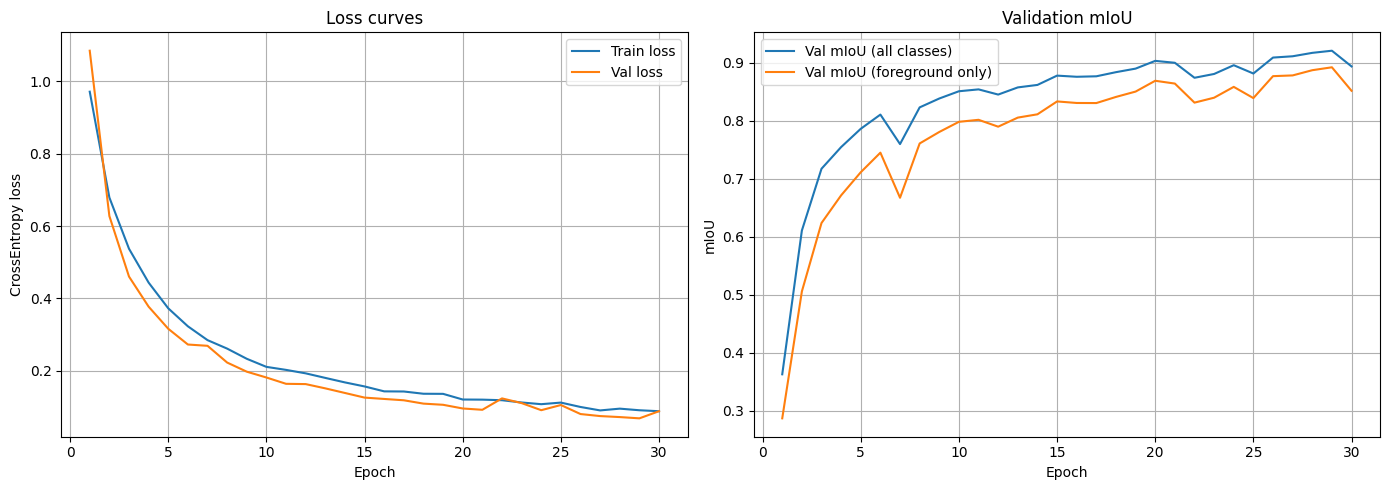

In [19]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ran, history["train_loss"], label="Train loss")
ax1.plot(epochs_ran, history["val_loss"],   label="Val loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("CrossEntropy loss")
ax1.set_title("Loss curves"); ax1.legend(); ax1.grid(True)

ax2.plot(epochs_ran, history["val_miou"],    label="Val mIoU (all classes)")
ax2.plot(epochs_ran, history["val_fg_miou"], label="Val mIoU (foreground only)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("mIoU")
ax2.set_title("Validation mIoU"); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / "training_curves.png", dpi=120)
plt.show()

## 8 · Evaluation on Test Set

In [20]:
# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT_DIR / "resnet34_unet_best.pth", map_location=DEVICE))
model.eval()

test_loss_sum  = 0.0
test_miou_sum  = 0.0
test_fmiou_sum = 0.0

# Per-class confusion for pixel accuracy
confusion = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.long)

with torch.no_grad():
    for imgs, masks_gt in test_loader:
        imgs, masks_gt = imgs.to(DEVICE), masks_gt.to(DEVICE)
        logits = model(imgs)

        test_loss_sum  += criterion(logits, masks_gt).item()
        test_miou_sum  += compute_miou(logits, masks_gt)
        test_fmiou_sum += compute_fg_miou(logits, masks_gt)

        preds = logits.argmax(dim=1).view(-1).cpu()
        gts   = masks_gt.view(-1).cpu()
        for t, p in zip(gts, preds):
            confusion[t.item(), p.item()] += 1

n_test = len(test_loader)
test_loss    = test_loss_sum  / n_test
test_miou    = test_miou_sum  / n_test
test_fg_miou = test_fmiou_sum / n_test
pixel_acc    = confusion.diag().sum().item() / confusion.sum().item()

print("─" * 45)
print(f"Test CrossEntropy loss  : {test_loss:.4f}")
print(f"Test mIoU (all classes) : {test_miou:.4f}")
print(f"Test mIoU (fg only)     : {test_fg_miou:.4f}")
print(f"Test pixel accuracy     : {pixel_acc:.4f}")
print("─" * 45)

# Per-class IoU from confusion matrix
for cls in range(NUM_CLASSES):
    tp  = confusion[cls, cls].item()
    fp  = confusion[:, cls].sum().item() - tp
    fn  = confusion[cls, :].sum().item() - tp
    iou = tp / max(tp + fp + fn, 1)
    print(f"  IoU [{CLASS_NAMES[cls]:>16}]: {iou:.4f}")

─────────────────────────────────────────────
Test CrossEntropy loss  : 0.0802
Test mIoU (all classes) : 0.9058
Test mIoU (fg only)     : 0.8707
Test pixel accuracy     : 0.9753
─────────────────────────────────────────────
  IoU [      background]: 0.9759
  IoU [     space-empty]: 0.8705
  IoU [  space-occupied]: 0.8771


## 9 · Visual Predictions on Test Samples

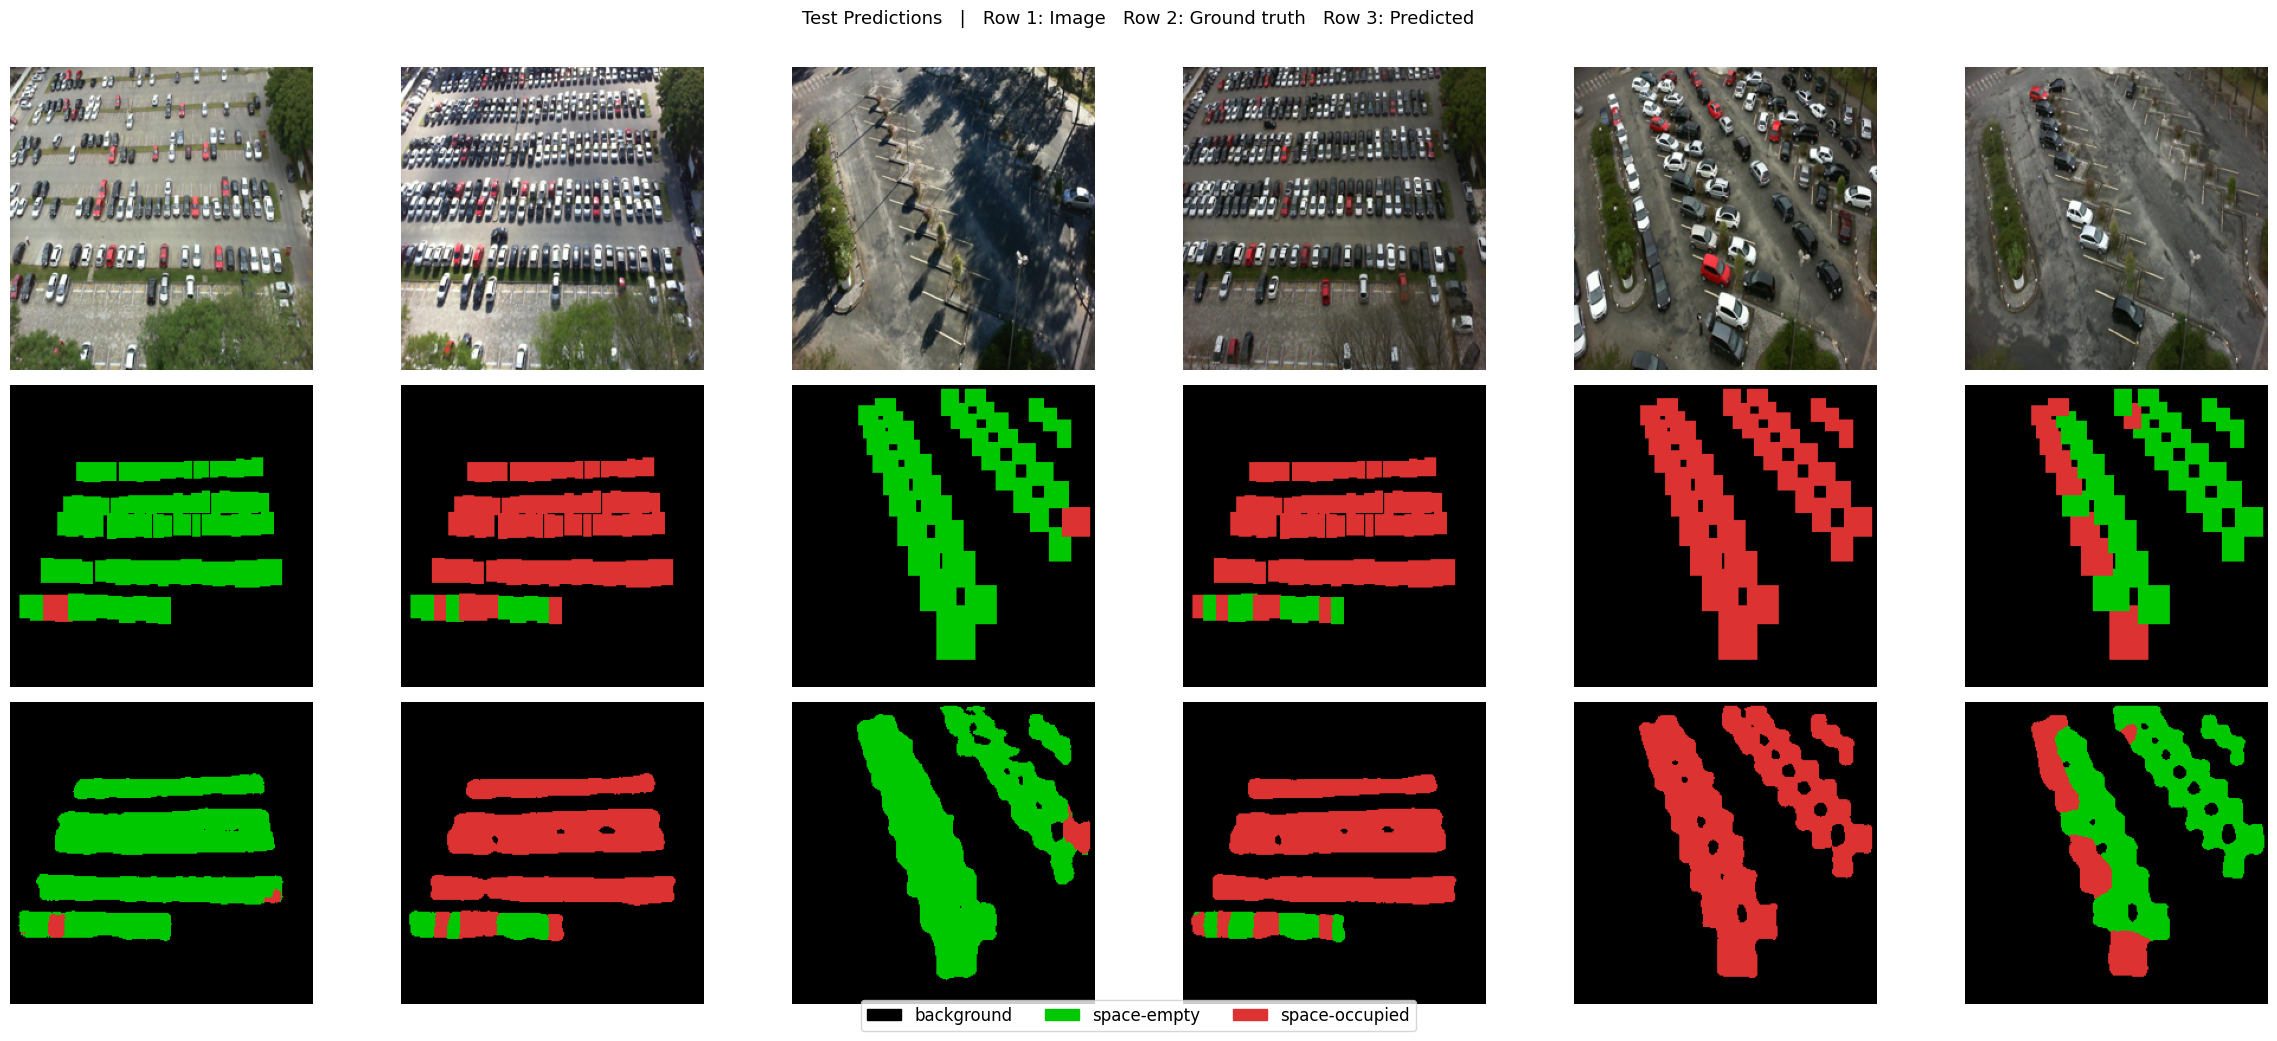

In [21]:
n_show = 6
sample_imgs, sample_gt_masks = next(iter(test_loader))

model.eval()
with torch.no_grad():
    pred_logits = model(sample_imgs.to(DEVICE))
    pred_masks  = pred_logits.argmax(dim=1).cpu()

fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 10))
fig.suptitle("Test Predictions   |   Row 1: Image   Row 2: Ground truth   Row 3: Predicted",
             fontsize=13, y=1.01)

for i in range(n_show):
    axes[0, i].imshow(denormalise(sample_imgs[i]))
    axes[0, i].axis("off")

    axes[1, i].imshow(mask_to_rgb(sample_gt_masks[i].numpy()))
    axes[1, i].axis("off")

    axes[2, i].imshow(mask_to_rgb(pred_masks[i].numpy()))
    axes[2, i].axis("off")

legend = [
    mpatches.Patch(color=CLASS_COLORS[j] / 255, label=CLASS_NAMES[j])
    for j in range(NUM_CLASSES)
]
fig.legend(handles=legend, loc="lower center", ncol=3, fontsize=12, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / "test_predictions.png", dpi=120, bbox_inches="tight")
plt.show()

## 10 · Save Final Model

In [22]:
save_path = CHECKPOINT_DIR / "resnet34_unet_final.pth"
torch.save({
    "model_state_dict" : model.state_dict(),
    "encoder"          : "resnet34",
    "encoder_weights"  : "imagenet",
    "in_channels"      : IN_CHANNELS,
    "num_classes"      : NUM_CLASSES,
    "class_names"      : CLASS_NAMES,
    "img_size"         : IMG_SIZE,
    "best_val_miou"    : best_val_miou,
    "test_miou"        : test_miou,
    "test_fg_miou"     : test_fg_miou,
}, save_path)

print(f"Saved to: {save_path}")
print()
print("To reload:")
print("  ckpt  = torch.load('resnet34_unet_final.pth', map_location='cpu')")
print("  model = smp.Unet(encoder_name='resnet34', in_channels=3, classes=3)")
print("  model.load_state_dict(ckpt['model_state_dict'])")

Saved to: ../checkpoints/resnet34_unet_final.pth

To reload:
  ckpt  = torch.load('resnet34_unet_final.pth', map_location='cpu')
  model = smp.Unet(encoder_name='resnet34', in_channels=3, classes=3)
  model.load_state_dict(ckpt['model_state_dict'])
